# Data Preparation 

### Selecting the Timeseries Attributes 

In [1]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

files = ['F.csv', 'Np.csv', 'P4.csv', 'P5.csv', 'P6.csv',
         'Tp.csv', 'V.csv', 'Vx.csv', 'Xl.csv', 'Xs.csv']

label_map = {
    'NSEP': 0, 'gt10': 1, 'gt30': 2, 'gt60': 3, 'gt100': 4
}

input_dir  = './dataset'
output_dir = './output'
os.makedirs(output_dir, exist_ok=True)

for filename in files:
    filepath = os.path.join(input_dir, filename)

    # All files have a header row — use header=0 for all
    df = pd.read_csv(filepath, header=0)

    # First column is the label, last 288 are the time series
    label_col       = df.iloc[:, 0].map(label_map)
    timeseries_cols = df.iloc[:, -288:].apply(
        lambda col: pd.to_numeric(col, errors='coerce'), axis=0
    )

    result = pd.concat([label_col.reset_index(drop=True),
                        timeseries_cols.reset_index(drop=True)], axis=1)
    result.columns = range(result.shape[1])

    out_path = os.path.join(output_dir, filename)
    result.to_csv(out_path, index=False, header=False, float_format='%.12g')

    ts_vals   = timeseries_cols.values.astype(float)
    nan_count = np.isnan(ts_vals).sum()
    print(f"{filename:<10}  shape={result.shape}  |  "
          f"min={np.nanmin(ts_vals):.4e}  max={np.nanmax(ts_vals):.4e}  "
          f"mean={np.nanmean(ts_vals):.4e}  |  NaNs={nan_count}")

print("\nDone!")

F.csv       shape=(17794, 289)  |  min=2.7000e-01  max=1.0000e+04  mean=5.1045e+02  |  NaNs=0
Np.csv      shape=(17794, 289)  |  min=3.0000e-02  max=6.9720e+01  mean=5.8444e+00  |  NaNs=0
P4.csv      shape=(17794, 289)  |  min=0.0000e+00  max=1.0300e+03  mean=1.0439e+00  |  NaNs=0
P5.csv      shape=(17794, 289)  |  min=0.0000e+00  max=9.9300e+01  mean=1.0275e-01  |  NaNs=0
P6.csv      shape=(17794, 289)  |  min=5.7900e-04  max=4.3500e+00  mean=5.5823e-03  |  NaNs=0
Tp.csv      shape=(17794, 289)  |  min=9.2000e+02  max=7.7280e+06  mean=1.0480e+05  |  NaNs=0
V.csv       shape=(17794, 289)  |  min=2.3540e+02  max=1.1305e+03  mean=4.4244e+02  |  NaNs=0
Vx.csv      shape=(17794, 289)  |  min=-1.1262e+03  max=-2.3170e+02  mean=-4.4101e+02  |  NaNs=0
Xl.csv      shape=(17794, 289)  |  min=0.0000e+00  max=1.8400e-03  mean=1.6714e-06  |  NaNs=0
Xs.csv      shape=(17794, 289)  |  min=0.0000e+00  max=4.8100e-04  mean=1.1529e-07  |  NaNs=0

Done!


### Missing value analysis 

In [2]:
import pandas as pd
import numpy as np

files = ['F.csv', 'Np.csv', 'P4.csv', 'P5.csv', 'P6.csv',
         'Tp.csv', 'V.csv', 'Vx.csv', 'Xl.csv', 'Xs.csv']

input_dir = './output'

print(f"{'File':<12} {'Rows':>7} {'Total Cells':>12} {'Missing':>10} {'Missing %':>10} {'Rows w/ Missing':>16}")
print("-" * 72)

for filename in files:
    filepath = f"{input_dir}/{filename}"
    try:
        df = pd.read_csv(filepath, header=None, low_memory=False)
        df = df.apply(pd.to_numeric, errors='coerce')

        total_cells   = df.size
        missing_cells = df.isna().sum().sum()
        missing_pct   = 100 * missing_cells / total_cells
        rows_affected = df.isna().any(axis=1).sum()

        print(f"{filename:<12} {len(df):>7} {total_cells:>12,} {missing_cells:>10,} {missing_pct:>9.2f}% {rows_affected:>16,}")

    except FileNotFoundError:
        print(f"{filename:<12} [FILE NOT FOUND]")

print("-" * 72)
print("\nDone!")

File            Rows  Total Cells    Missing  Missing %  Rows w/ Missing
------------------------------------------------------------------------
F.csv          17794    5,142,466          0      0.00%                0
Np.csv         17794    5,142,466          0      0.00%                0
P4.csv         17794    5,142,466          0      0.00%                0
P5.csv         17794    5,142,466          0      0.00%                0
P6.csv         17794    5,142,466          0      0.00%                0
Tp.csv         17794    5,142,466          0      0.00%                0
V.csv          17794    5,142,466          0      0.00%                0
Vx.csv         17794    5,142,466          0      0.00%                0
Xl.csv         17794    5,142,466          0      0.00%                0
Xs.csv         17794    5,142,466          0      0.00%                0
------------------------------------------------------------------------

Done!


### tSNE plots of classes

  ✓ [F.csv] t-SNE done — 2169 samples  (NSEP=2000  SEP=169)
  ✓ [Np.csv] t-SNE done — 2169 samples  (NSEP=2000  SEP=169)
  ✓ [P4.csv] t-SNE done — 2169 samples  (NSEP=2000  SEP=169)
  ✓ [P5.csv] t-SNE done — 2169 samples  (NSEP=2000  SEP=169)
  ✓ [P6.csv] t-SNE done — 2169 samples  (NSEP=2000  SEP=169)
  ✓ [Tp.csv] t-SNE done — 2169 samples  (NSEP=2000  SEP=169)
  ✓ [V.csv] t-SNE done — 2169 samples  (NSEP=2000  SEP=169)
  ✓ [Vx.csv] t-SNE done — 2169 samples  (NSEP=2000  SEP=169)
  ✓ [Xl.csv] t-SNE done — 2169 samples  (NSEP=2000  SEP=169)
  ✓ [Xs.csv] t-SNE done — 2169 samples  (NSEP=2000  SEP=169)


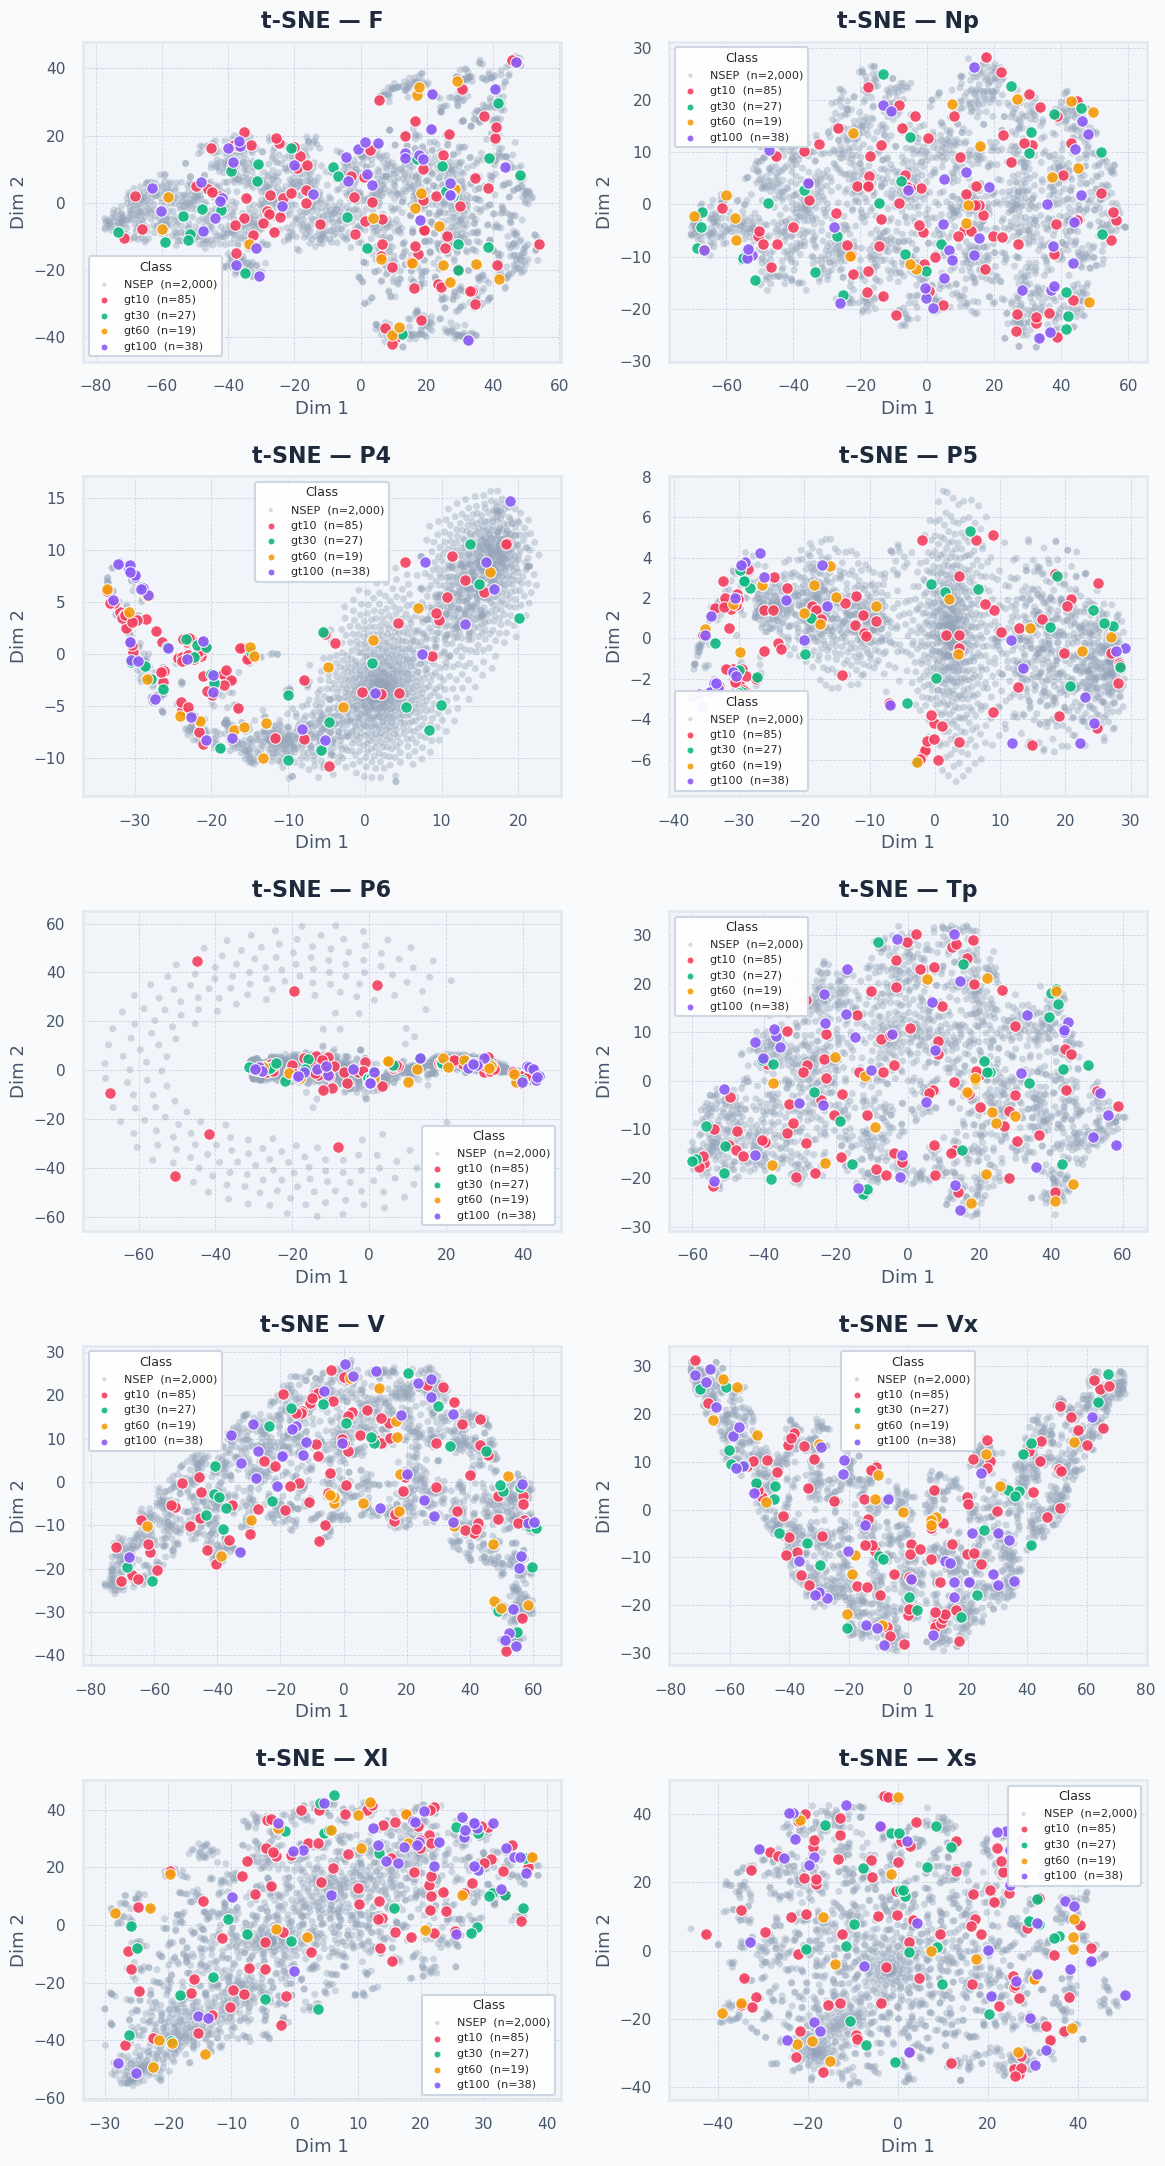

[DONE] F.csv
[DONE] Np.csv
[DONE] P4.csv
[DONE] P5.csv
[DONE] P6.csv
[DONE] Tp.csv
[DONE] V.csv
[DONE] Vx.csv
[DONE] Xl.csv
[DONE] Xs.csv
  Saved grid → ./tsne_plots/tsne_all_5x2.png

All done!


In [12]:
import warnings
warnings.filterwarnings('ignore')
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

files = ['F.csv', 'Np.csv', 'P4.csv', 'P5.csv', 'P6.csv',
         'Tp.csv', 'V.csv', 'Vx.csv', 'Xl.csv', 'Xs.csv']

input_dir  = './output'
output_dir = './tsne_plots'
os.makedirs(output_dir, exist_ok=True)

label_names  = {0: 'NSEP', 1: 'gt10', 2: 'gt30', 3: 'gt60', 4: 'gt100'}
label_colors = {
    0: '#94A3B8',
    1: '#F43F5E',
    2: '#10B981',
    3: '#F59E0B',
    4: '#8B5CF6',
}

DOT_SMALL = 25
DOT_BIG   = 70
log       = []
rng       = np.random.default_rng(42)

# ── Collect all t-SNE results ─────────────────────────────────
tsne_results = []

for filename in files:
    filepath = f"{input_dir}/{filename}"
    if not os.path.exists(filepath):
        log.append(f"[SKIP] {filename} not found")
        tsne_results.append(None)
        continue

    devnull = open(os.devnull, 'w')
    old_out, old_err = sys.stdout, sys.stderr
    sys.stdout, sys.stderr = devnull, devnull
    try:
        df = pd.read_csv(filepath, header=None, low_memory=False)
        df = df.iloc[1:].reset_index(drop=True)
        df = df.apply(pd.to_numeric, errors='coerce')
        df = df.dropna()
        labels = df.iloc[:, 0].astype(int).values
        X      = df.iloc[:, 1:].values

        # ── Subsample NSEP to 500 ──
        nsep_idx = np.where(labels == 0)[0]
        sep_idx  = np.where(labels != 0)[0]
        if len(nsep_idx) > 2000:
            nsep_idx = rng.choice(nsep_idx, size=2000, replace=False)
        keep_idx = np.sort(np.concatenate([nsep_idx, sep_idx]))
        X        = X[keep_idx]
        labels   = labels[keep_idx]

        tsne = TSNE(n_components=2, random_state=42, perplexity=30,
                    max_iter=1000, verbose=0)
        X_2d = tsne.fit_transform(X)
        tsne_results.append((X_2d, labels, filename))
    except Exception as e:
        tsne_results.append(None)
        log.append(f"[ERROR] {filename}: {e}")
    finally:
        sys.stdout, sys.stderr = old_out, old_err
        devnull.close()

    if tsne_results[-1] is not None:
        print(f"  ✓ [{filename}] t-SNE done — {len(labels)} samples  "
              f"(NSEP={(labels==0).sum()}  SEP={(labels!=0).sum()})", flush=True)
    log.append(f"[DONE] {filename}")

# ── Plot individual figures ───────────────────────────────────
for item in tsne_results:
    if item is None:
        continue
    X_2d, labels, filename = item

    sns.set_theme(style='whitegrid', context='talk', font='DejaVu Sans')
    fig, ax = plt.subplots(figsize=(9, 7))
    fig.patch.set_facecolor('#F8FAFC')
    ax.set_facecolor('#F1F5F9')

    for label_id in sorted(label_names.keys()):
        mask = labels == label_id
        if mask.sum() == 0:
            continue
        is_nsep = label_id == 0
        ax.scatter(
            X_2d[mask, 0], X_2d[mask, 1],
            c=label_colors[label_id],
            s=DOT_SMALL if is_nsep else DOT_BIG,
            label=f"{label_names[label_id]}  (n={mask.sum():,})",
            alpha=0.4 if is_nsep else 0.9,
            edgecolors='none' if is_nsep else 'white',
            linewidths=0 if is_nsep else 0.8,
            zorder=1 if is_nsep else 2
        )

    ax.set_title(f't-SNE — {filename.replace(".csv", "")}',
                 fontsize=18, fontweight='bold', color='#1E293B', pad=16)
    ax.set_xlabel('t-SNE Dimension 1', fontsize=14, color='#475569', labelpad=10)
    ax.set_ylabel('t-SNE Dimension 2', fontsize=14, color='#475569', labelpad=10)
    ax.tick_params(colors='#475569', labelsize=12)
    for spine in ax.spines.values():
        spine.set_color('#E2E8F0')
    ax.yaxis.grid(True, color='#CBD5E1', linewidth=0.6, linestyle='--')
    ax.xaxis.grid(True, color='#CBD5E1', linewidth=0.6, linestyle='--')
    legend = ax.legend(
        title='Class', title_fontsize=10,
        fontsize=9, loc='best',
        framealpha=0.95, edgecolor='#CBD5E1',
        facecolor='white', markerscale=0.7,
    )
    legend.get_title().set_color('#1E293B')
    plt.tight_layout()
    plt.savefig(f'{output_dir}/{filename.replace(".csv", "_tsne.png")}',
                dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.close()

# ── Combined 5×2 grid figure ─────────────────────────────────
valid_results = [r for r in tsne_results if r is not None]

sns.set_theme(style='whitegrid', context='talk', font='DejaVu Sans')
fig, axes = plt.subplots(5, 2, figsize=(12, 22))
fig.patch.set_facecolor('#F8FAFC')
axes_flat = axes.flatten()

for idx, (X_2d, labels, filename) in enumerate(valid_results):
    ax = axes_flat[idx]
    ax.set_facecolor('#F1F5F9')

    for label_id in sorted(label_names.keys()):
        mask = labels == label_id
        if mask.sum() == 0:
            continue
        is_nsep = label_id == 0
        ax.scatter(
            X_2d[mask, 0], X_2d[mask, 1],
            c=label_colors[label_id],
            s=DOT_SMALL if is_nsep else DOT_BIG,
            label=f"{label_names[label_id]}  (n={mask.sum():,})",
            alpha=0.4 if is_nsep else 0.9,
            edgecolors='none' if is_nsep else 'white',
            linewidths=0 if is_nsep else 0.8,
            zorder=1 if is_nsep else 2
        )

    ax.set_title(f't-SNE — {filename.replace(".csv", "")}',
                 fontsize=16, fontweight='bold', color='#1E293B', pad=10)
    ax.set_xlabel('Dim 1', fontsize=13, color='#475569')
    ax.set_ylabel('Dim 2', fontsize=13, color='#475569')
    ax.tick_params(colors='#475569', labelsize=11)
    for spine in ax.spines.values():
        spine.set_color('#E2E8F0')
    ax.yaxis.grid(True, color='#CBD5E1', linewidth=0.6, linestyle='--')
    ax.xaxis.grid(True, color='#CBD5E1', linewidth=0.6, linestyle='--')
    ax.legend(title='Class', title_fontsize=9, fontsize=8,
              loc='best', framealpha=0.95,
              edgecolor='#CBD5E1', facecolor='white',
              markerscale=0.6)

for idx in range(len(valid_results), len(axes_flat)):
    axes_flat[idx].set_visible(False)


plt.tight_layout()
plt.savefig(f'{output_dir}/tsne_all_5x2.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
plt.close()

log.append(f"  Saved grid → {output_dir}/tsne_all_5x2.png")
log.append("\nAll done!")
print('\n'.join(log))

### Combining files to create an MVTS

In [3]:
import pandas as pd
import numpy as np
import pickle
import os

files = ['F.csv', 'Np.csv', 'P4.csv', 'P5.csv', 'P6.csv',
         'Tp.csv', 'V.csv', 'Vx.csv', 'Xl.csv', 'Xs.csv']

input_dir  = './output'
output_dir = './mvts'
os.makedirs(output_dir, exist_ok=True)

all_X = []
all_y = []

for filename in files:
    filepath = f"{input_dir}/{filename}"
    if not os.path.exists(filepath):
        print(f"[SKIP] {filename} not found")
        continue

    print(f"Loading: {filename}")

    df = pd.read_csv(filepath, header=None, low_memory=False)
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.dropna()

    labels = df.iloc[:, 0].astype(int).values   # (num_samples,)
    ts     = df.iloc[:, 1:].values               # (num_samples, 288)

    all_X.append(ts)
    all_y.append(labels)

    print(f"  Samples: {len(labels)}  |  Timesteps: {ts.shape[1]}")

# Stack all files
# Each file = one feature → shape becomes (num_samples, num_timesteps, num_features)
X = np.stack(all_X, axis=-1)   # (num_samples, 288, 10)
y = all_y[0]                    # labels are the same across all files

print(f"\nFinal dataset shape : {X.shape}  →  (samples, timesteps, features)")
print(f"Labels shape        : {y.shape}")
print(f"Label distribution  : {dict(zip(*np.unique(y, return_counts=True)))}")

# Save X as pickle
pickle_path = os.path.join(output_dir, 'X.pkl')
with open(pickle_path, 'wb') as f:
    pickle.dump(X, f)
print(f"\nSaved X → {pickle_path}")

# Save y as 1D csv
labels_path = os.path.join(output_dir, 'y.csv')
pd.Series(y).to_csv(labels_path, index=False, header=False)
print(f"Saved y → {labels_path}")

print("\nAll done!")

Loading: F.csv
  Samples: 17794  |  Timesteps: 288
Loading: Np.csv
  Samples: 17794  |  Timesteps: 288
Loading: P4.csv
  Samples: 17794  |  Timesteps: 288
Loading: P5.csv
  Samples: 17794  |  Timesteps: 288
Loading: P6.csv
  Samples: 17794  |  Timesteps: 288
Loading: Tp.csv
  Samples: 17794  |  Timesteps: 288
Loading: V.csv
  Samples: 17794  |  Timesteps: 288
Loading: Vx.csv
  Samples: 17794  |  Timesteps: 288
Loading: Xl.csv
  Samples: 17794  |  Timesteps: 288
Loading: Xs.csv
  Samples: 17794  |  Timesteps: 288

Final dataset shape : (17794, 288, 10)  →  (samples, timesteps, features)
Labels shape        : (17794,)
Label distribution  : {np.int64(0): np.int64(17625), np.int64(1): np.int64(85), np.int64(2): np.int64(27), np.int64(3): np.int64(19), np.int64(4): np.int64(38)}

Saved X → ./mvts/X.pkl
Saved y → ./mvts/y.csv

All done!


### tSNE plots of classes using MVTS

Running PCA …


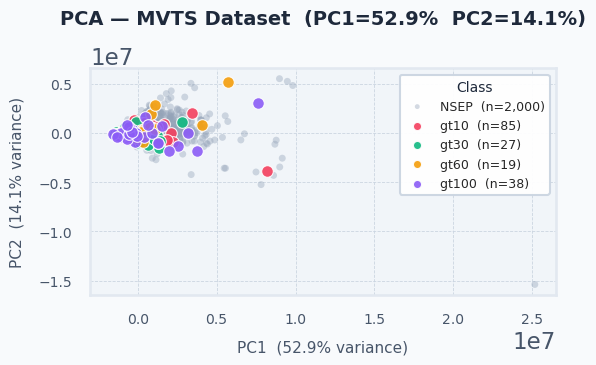

✅  PCA done
Running t-SNE …


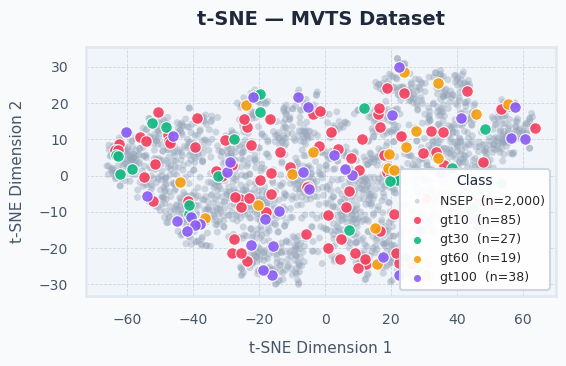

✅  t-SNE done


In [16]:
import warnings
warnings.filterwarnings('ignore')
import os
import contextlib
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

input_dir  = './mvts'
output_dir = './plots'
os.makedirs(output_dir, exist_ok=True)

# ── Load data ─────────────────────────────────────────────────
with open(f'{input_dir}/X.pkl', 'rb') as f:
    X = pickle.load(f)
y = pd.read_csv(f'{input_dir}/y.csv', header=None).values.flatten().astype(int)

# ── Subsample NSEP to 2000 ────────────────────────────────────
rng      = np.random.default_rng(42)
nsep_idx = np.where(y == 0)[0]
sep_idx  = np.where(y != 0)[0]
if len(nsep_idx) > 2000:
    nsep_idx = rng.choice(nsep_idx, size=2000, replace=False)
keep_idx = np.sort(np.concatenate([nsep_idx, sep_idx]))
X        = X[keep_idx]
y        = y[keep_idx]

X_flat = X.reshape(X.shape[0], -1)

label_names  = {0: 'NSEP', 1: 'gt10', 2: 'gt30', 3: 'gt60', 4: 'gt100'}
label_colors = {
    0: '#94A3B8',
    1: '#F43F5E',
    2: '#10B981',
    3: '#F59E0B',
    4: '#8B5CF6',
}

DOT_SMALL = 25
DOT_BIG   = 70

def plot_embedding(X_2d, y, title, filename, xlabel, ylabel):
    sns.set_theme(style='whitegrid', context='talk', font='DejaVu Sans')
    fig, ax = plt.subplots(figsize=(6, 4))
    fig.patch.set_facecolor('#F8FAFC')
    ax.set_facecolor('#F1F5F9')

    for label_id in sorted(label_names.keys()):
        mask = y == label_id
        if mask.sum() == 0:
            continue
        is_nsep = label_id == 0
        ax.scatter(
            X_2d[mask, 0], X_2d[mask, 1],
            c=label_colors[label_id],
            s=DOT_SMALL if is_nsep else DOT_BIG,
            label=f"{label_names[label_id]}  (n={mask.sum():,})",
            alpha=0.4 if is_nsep else 0.9,
            edgecolors='none' if is_nsep else 'white',
            linewidths=0 if is_nsep else 0.8,
            zorder=1 if is_nsep else 2
        )

    ax.set_title(title, fontsize=14, fontweight='bold', color='#1E293B', pad=16)
    ax.set_xlabel(xlabel, fontsize=11, color='#475569', labelpad=10)
    ax.set_ylabel(ylabel, fontsize=11, color='#475569', labelpad=10)
    ax.tick_params(colors='#475569', labelsize=10)
    for spine in ax.spines.values():
        spine.set_color('#E2E8F0')
    ax.yaxis.grid(True, color='#CBD5E1', linewidth=0.6, linestyle='--')
    ax.xaxis.grid(True, color='#CBD5E1', linewidth=0.6, linestyle='--')
    legend = ax.legend(
        title='Class', title_fontsize=10,
        fontsize=9, loc='best',
        framealpha=0.95, edgecolor='#CBD5E1',
        facecolor='white', markerscale=0.7,
    )
    legend.get_title().set_color('#1E293B')
    plt.tight_layout()
    plt.savefig(f'{output_dir}/{filename}', dpi=150,
                bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    plt.close()

def silence(func, *args, **kwargs):
    with open(os.devnull, 'w') as devnull:
        with contextlib.redirect_stdout(devnull), contextlib.redirect_stderr(devnull):
            return func(*args, **kwargs)

# ── PCA ───────────────────────────────────────────────────────
print("Running PCA …", flush=True)
pca   = PCA(n_components=2, random_state=42)
X_pca = silence(pca.fit_transform, X_flat)
var   = pca.explained_variance_ratio_ * 100
plot_embedding(
    X_pca, y,
    title=f'PCA — MVTS Dataset  (PC1={var[0]:.1f}%  PC2={var[1]:.1f}%)',
    filename='pca.png',
    xlabel=f'PC1  ({var[0]:.1f}% variance)',
    ylabel=f'PC2  ({var[1]:.1f}% variance)'
)
print("✅  PCA done", flush=True)

# ── t-SNE ─────────────────────────────────────────────────────
print("Running t-SNE …", flush=True)
pca50   = PCA(n_components=50, random_state=42)
X_pca50 = silence(pca50.fit_transform, X_flat)
tsne    = TSNE(n_components=2, random_state=42, perplexity=30,
               max_iter=1000, verbose=0)
X_tsne  = silence(tsne.fit_transform, X_pca50)
plot_embedding(
    X_tsne, y,
    title='t-SNE — MVTS Dataset',
    filename='tsne.png',
    xlabel='t-SNE Dimension 1',
    ylabel='t-SNE Dimension 2'
)
print("✅  t-SNE done", flush=True)

### Class Distribution

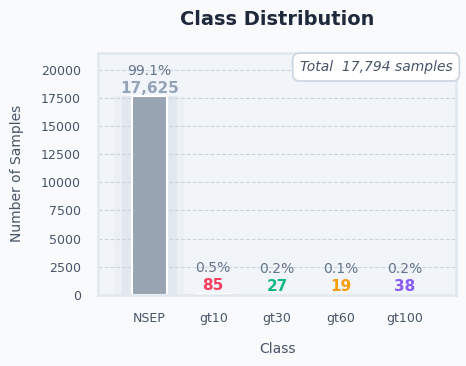

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import os

input_dir  = './mvts'
output_dir = './plots'
os.makedirs(output_dir, exist_ok=True)

y = pd.read_csv(f'{input_dir}/y.csv', header=None).values.flatten().astype(int)

label_names  = {0: 'NSEP', 1: 'gt10', 2: 'gt30', 3: 'gt60', 4: 'gt100'}
label_colors = {
    0: '#94A3B8',
    1: '#F43F5E',
    2: '#10B981',
    3: '#F59E0B',
    4: '#8B5CF6',
}

unique, counts = np.unique(y, return_counts=True)
total = counts.sum()

df_plot = pd.DataFrame({
    'Class'  : [label_names[i] for i in unique],
    'Samples': counts,
    'Color'  : [label_colors[i] for i in unique]
})

sns.set_theme(style='whitegrid', context='talk', font='DejaVu Sans')
fig, ax = plt.subplots(figsize=(5, 4))
fig.patch.set_facecolor('#F8FAFC')
ax.set_facecolor('#F1F5F9')

sns.barplot(
    data=df_plot,
    x='Class', y='Samples',
    palette=df_plot['Color'].tolist(),
    edgecolor='white', linewidth=1.5,
    ax=ax, width=0.55
)

for bar, label_id in zip(ax.patches, unique):
    cx = bar.get_x() + bar.get_width() / 2
    for alpha, extra_w in [(0.10, 0.30), (0.05, 0.55)]:
        ax.bar(cx, bar.get_height(),
               width=bar.get_width() + extra_w,
               color=label_colors[label_id],
               alpha=alpha, zorder=0, edgecolor='none')

for bar, count, label_id in zip(ax.patches, counts, unique):
    pct = 100 * count / total
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total * 0.004,
        f'{count:,}',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold',
        color=label_colors[label_id],
    )
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total * 0.004 + counts.max() * 0.09,
        f'{pct:.1f}%',
        ha='center', va='bottom',
        fontsize=10, color='#64748B',
    )

ax.yaxis.grid(True, color='#CBD5E1', linewidth=0.8, linestyle='--')
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_color('#E2E8F0')

ax.set_title('Class Distribution', fontsize=14, fontweight='bold',
             color='#1E293B', pad=20)
ax.set_xlabel('Class', fontsize=10, color='#475569', labelpad=12)
ax.set_ylabel('Number of Samples', fontsize=10, color='#475569', labelpad=12)
ax.tick_params(colors='#475569', labelsize=9)
ax.set_ylim(0, counts.max() * 1.22)

ax.text(0.99, 0.97, f'Total  {total:,} samples',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=10, color='#475569', fontstyle='italic',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                  edgecolor='#CBD5E1', linewidth=1.2))

plt.tight_layout()
plt.savefig(f'{output_dir}/class_distribution.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()   # ← display inline
plt.close()

### Multiclass to Binary 

In [4]:
import pandas as pd
import numpy as np
import pickle
import os
from collections import Counter

variants = [
    ('./mvts', './mvts_binary'),
]

for input_dir, output_dir in variants:
    print(f"\n{'='*55}")
    print(f"Input  : {input_dir}")
    print(f"Output : {output_dir}")
    print('='*55)
    os.makedirs(output_dir, exist_ok=True)
    with open(f'{input_dir}/X.pkl', 'rb') as f:
        X = pickle.load(f)
    y = pd.read_csv(f'{input_dir}/y.csv', header=None).values.flatten().astype(int)
    print(f"Original Distribution : {Counter(y)}")
    y_binary = np.where(y > 0, 1, 0)
    print(f"Binary Distribution   : {Counter(y_binary)}")
    with open(f'{output_dir}/X.pkl', 'wb') as f:
        pickle.dump(X, f)
    pd.Series(y_binary).to_csv(f'{output_dir}/y.csv', index=False, header=False)
    print(f"Saved X → {output_dir}/X.pkl")
    print(f"Saved y → {output_dir }/y.csv")

print("\nAll done!")


Input  : ./mvts
Output : ./mvts_binary
Original Distribution : Counter({np.int64(0): 17625, np.int64(1): 85, np.int64(4): 38, np.int64(2): 27, np.int64(3): 19})
Binary Distribution   : Counter({np.int64(0): 17625, np.int64(1): 169})
Saved X → ./mvts_binary/X.pkl
Saved y → ./mvts_binary/y.csv

All done!


### Separate the classes 

In [5]:
import numpy as np
import pickle
import pandas as pd
import os
from collections import Counter

variants = [
    './mvts_binary',
]

for input_dir in variants:
    print(f"\n{'='*55}")
    print(f"Input : {input_dir}")
    print('='*55)
    with open(f'{input_dir}/X.pkl', 'rb') as f:
        X = pickle.load(f)
    y = pd.read_csv(f'{input_dir}/y.csv', header=None).values.flatten().astype(int)
    print(f"Full Dataset Distribution : {Counter(y)}")
    nsep_idx = np.where(y == 0)[0]
    sep_idx  = np.where(y == 1)[0]
    X_nsep = X[nsep_idx];  y_nsep = y[nsep_idx]
    X_sep  = X[sep_idx];   y_sep  = y[sep_idx]
    print(f"NSEP (Class 0) Samples    : {X_nsep.shape[0]:,}")
    print(f"SEP  (Class 1) Samples    : {X_sep.shape[0]:,}")
    with open(f'{input_dir}/X_nsep.pkl', 'wb') as f:
        pickle.dump(X_nsep, f)
    with open(f'{input_dir}/X_sep.pkl', 'wb') as f:
        pickle.dump(X_sep, f)
    pd.Series(y_nsep).to_csv(f'{input_dir}/y_nsep.csv', index=False, header=False)
    pd.Series(y_sep).to_csv(f'{input_dir}/y_sep.csv',   index=False, header=False)
    print(f"Saved X_nsep, X_sep, y_nsep, y_sep → {input_dir}/")

print("\nAll done!")


Input : ./mvts_binary
Full Dataset Distribution : Counter({np.int64(0): 17625, np.int64(1): 169})
NSEP (Class 0) Samples    : 17,625
SEP  (Class 1) Samples    : 169
Saved X_nsep, X_sep, y_nsep, y_sep → ./mvts_binary/

All done!


### Train-test split (70 - 10 - 20) and shuffling

In [6]:
import numpy as np
import pandas as pd
import pickle
import os
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

variants = [
    ('./mvts_binary',                './final_split_data_noNorm'),
]

def save_bundle(X_data, y_data, filepath):
    with open(filepath, 'wb') as f:
        pickle.dump({'X': X_data, 'y': y_data}, f)
    print(f"Saved : {filepath}")

for input_dir, output_dir in variants:
    print(f"\n{'='*55}")
    print(f"Input  : {input_dir}")
    print(f"Output : {output_dir}")
    print('='*55)
    os.makedirs(output_dir, exist_ok=True)
    with open(f'{input_dir}/X_nsep.pkl', 'rb') as f:
        X_nsep = pickle.load(f)
    with open(f'{input_dir}/X_sep.pkl', 'rb') as f:
        X_sep = pickle.load(f)
    y_nsep = pd.read_csv(f'{input_dir}/y_nsep.csv', header=None).values.flatten().astype(int)
    y_sep  = pd.read_csv(f'{input_dir}/y_sep.csv',  header=None).values.flatten().astype(int)
    print(f"NSEP samples : {X_nsep.shape[0]:,}")
    print(f"SEP  samples : {X_sep.shape[0]:,}")
    # ── Step 1: Split NSEP 70-10-20 ──────────────────────────────────────────
    X_nsep_tv, X_nsep_test, y_nsep_tv, y_nsep_test = train_test_split(
        X_nsep, y_nsep, test_size=0.20, random_state=42, shuffle=False)
    X_nsep_train, X_nsep_val, y_nsep_train, y_nsep_val = train_test_split(
        X_nsep_tv, y_nsep_tv, test_size=0.125, random_state=42, shuffle=False)
    # ── Step 2: Split SEP 70-10-20 ───────────────────────────────────────────
    X_sep_tv, X_sep_test, y_sep_tv, y_sep_test = train_test_split(
        X_sep, y_sep, test_size=0.20, random_state=42, shuffle=False)
    X_sep_train, X_sep_val, y_sep_train, y_sep_val = train_test_split(
        X_sep_tv, y_sep_tv, test_size=0.125, random_state=42, shuffle=False)
    # ── Step 3: Combine ───────────────────────────────────────────────────────
    X_train = np.concatenate([X_nsep_train, X_sep_train], axis=0)
    y_train = np.concatenate([y_nsep_train, y_sep_train], axis=0)
    X_val   = np.concatenate([X_nsep_val,   X_sep_val],   axis=0)
    y_val   = np.concatenate([y_nsep_val,   y_sep_val],   axis=0)
    X_test  = np.concatenate([X_nsep_test,  X_sep_test],  axis=0)
    y_test  = np.concatenate([y_nsep_test,  y_sep_test],  axis=0)
    # ── Step 4: Shuffle ───────────────────────────────────────────────────────
    X_train, y_train = shuffle(X_train, y_train, random_state=42)
    X_val,   y_val   = shuffle(X_val,   y_val,   random_state=42)
    X_test,  y_test  = shuffle(X_test,  y_test,  random_state=42)
    print(f"\nTrain : {X_train.shape[0]:,} samples  |  {Counter(y_train)}")
    print(f"Val   : {X_val.shape[0]:,}   samples  |  {Counter(y_val)}")
    print(f"Test  : {X_test.shape[0]:,}  samples  |  {Counter(y_test)}")
    # ── Step 5: Save ─────────────────────────────────────────────────────────
    save_bundle(X_train, y_train, os.path.join(output_dir, 'train_set.pkl'))
    save_bundle(X_val,   y_val,   os.path.join(output_dir, 'val_set.pkl'))
    save_bundle(X_test,  y_test,  os.path.join(output_dir, 'test_set.pkl'))
    del X_nsep, X_sep, X_train, X_val, X_test

print("\nAll done!")


Input  : ./mvts_binary
Output : ./final_split_data_noNorm
NSEP samples : 17,625
SEP  samples : 169

Train : 12,455 samples  |  Counter({np.int64(0): 12337, np.int64(1): 118})
Val   : 1,780   samples  |  Counter({np.int64(0): 1763, np.int64(1): 17})
Test  : 3,559  samples  |  Counter({np.int64(0): 3525, np.int64(1): 34})
Saved : ./final_split_data_noNorm/train_set.pkl
Saved : ./final_split_data_noNorm/val_set.pkl
Saved : ./final_split_data_noNorm/test_set.pkl

All done!


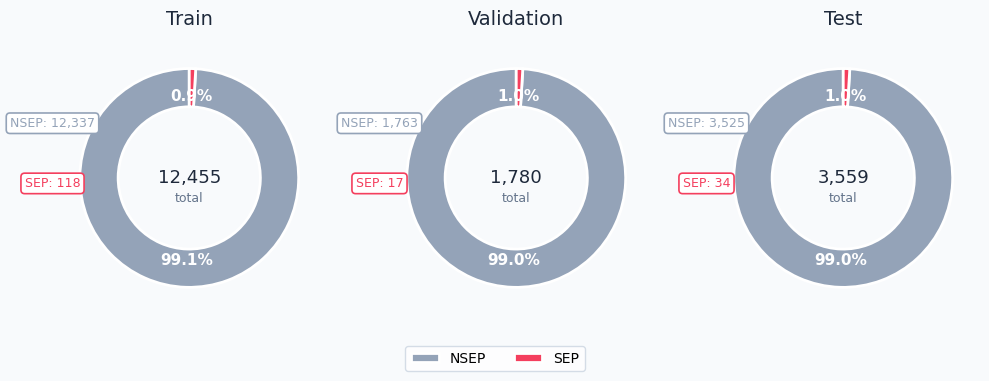

✅  Saved → ./plots/split_distribution_noNorm.png


In [7]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

input_dir  = './final_split_data_noNorm'
output_dir = './plots'
os.makedirs(output_dir, exist_ok=True)

# ── Load splits ──
def load_bundle(path):
    with open(path, 'rb') as f:
        d = pickle.load(f)
    return d['y']

y_train = load_bundle(f'{input_dir}/train_set.pkl')
y_val   = load_bundle(f'{input_dir}/val_set.pkl')
y_test  = load_bundle(f'{input_dir}/test_set.pkl')

splits = {
    'Train': y_train,
    'Validation'  : y_val,
    'Test' : y_test,
}

colors = ['#94A3B8', '#F43F5E']  # NSEP, SEP

# ── Plot ──
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
fig.patch.set_facecolor('#F8FAFC')

for ax, (split_name, y) in zip(axes, splits.items()):
    unique, counts = np.unique(y, return_counts=True)
    labels         = ['NSEP' if u == 0 else 'SEP' for u in unique]
    total          = counts.sum()

    wedges, texts, autotexts = ax.pie(
        counts,
        labels      = None,
        colors      = colors,
        autopct     = '%1.1f%%',
        startangle  = 90,
        pctdistance = 0.75,
        wedgeprops  = dict(width=0.35, edgecolor='white', linewidth=2),
    )

    for at in autotexts:
        at.set_fontsize(11)
        at.set_fontweight('bold')
        at.set_color('white')

    # center text
    ax.text(0, 0, f'{total:,}', ha='center', va='center',
            fontsize=13, color='#1E293B')
    ax.text(0, -0.18, 'total', ha='center', va='center',
            fontsize=9, color='#64748B')

    ax.set_title(split_name, fontsize=14,
                 color='#1E293B', pad=12)

    # count annotations
    for i, (count, label) in enumerate(zip(counts, labels)):
        ax.text(0, 0.7 - i * 0.22, f'{label}: {count:,}',
                ha='center', va='center',
                fontsize=9, color=colors[i],
                transform=ax.transAxes,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor=colors[i], linewidth=1.2))

# legend
fig.legend(['NSEP', 'SEP'], loc='lower center', ncol=2,
           fontsize=10, frameon=True,
           facecolor='white', edgecolor='#CBD5E1',
           bbox_to_anchor=(0.5, 0.1))

plt.tight_layout()
plt.savefig(f'{output_dir}/split_distribution_noNorm.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
plt.close()
print("✅  Saved → ./plots/split_distribution_noNorm.png")

### Hybrid Normalization

In [8]:
import numpy as np
import pickle
import os

# ---------------------------------------------------------
# Input/output directories
# ---------------------------------------------------------
input_dir = './final_split_data_noNorm'
output_dir = './final_split_data_HybridNorm'
os.makedirs(output_dir, exist_ok=True)

feature_names = ['F', 'Np', 'P4', 'P5', 'P6', 'Tp', 'V', 'Vx', 'Xl', 'Xs']

log_robust_features = ['F', 'Np', 'P4', 'P5', 'P6', 'Tp', 'Xl', 'Xs']
zscore_features = ['V', 'Vx']


# ---------------------------------------------------------
# Load saved bundles
# ---------------------------------------------------------
def load_bundle(path):
    with open(path, 'rb') as f:
        data = pickle.load(f)
    return data['X'], data['y']


X_train, y_train = load_bundle(os.path.join(input_dir, 'train_set.pkl'))
X_val, y_val     = load_bundle(os.path.join(input_dir, 'val_set.pkl'))
X_test, y_test   = load_bundle(os.path.join(input_dir, 'test_set.pkl'))

print("Before normalization:")
print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)


# ---------------------------------------------------------
# Fit normalizer using training set only
# ---------------------------------------------------------
def fit_hybrid_normalizer(X_train, feature_names):
    """
    X_train shape: (N, T, F)
    Fits one normalization rule per feature using training data only.
    """

    params = {}

    for j, name in enumerate(feature_names):
        values = X_train[:, :, j].reshape(-1).astype(float)

        if name in log_robust_features:
            # Use only positive values to estimate epsilon
            positive_values = values[values > 0]

            if len(positive_values) == 0:
                eps = 1e-8
            else:
                eps = np.percentile(positive_values, 0.1)

                if eps <= 0:
                    eps = 1e-8

            # If any value + eps is <= 0, shift safely
            min_value = np.nanmin(values)
            if min_value + eps <= 0:
                eps = abs(min_value) + 1e-8

            transformed = np.log10(values + eps)

            median = np.nanmedian(transformed)
            q1 = np.nanpercentile(transformed, 25)
            q3 = np.nanpercentile(transformed, 75)
            iqr = q3 - q1

            if iqr == 0 or np.isnan(iqr):
                iqr = 1.0

            params[name] = {
                'method': 'log_robust',
                'eps': eps,
                'median': median,
                'iqr': iqr
            }

        elif name in zscore_features:
            mean = np.nanmean(values)
            std = np.nanstd(values)

            if std == 0 or np.isnan(std):
                std = 1.0

            params[name] = {
                'method': 'zscore',
                'mean': mean,
                'std': std
            }

        else:
            raise ValueError(f"No normalization method defined for feature: {name}")

    return params


# ---------------------------------------------------------
# Apply fitted normalizer
# ---------------------------------------------------------
def apply_hybrid_normalizer(X, feature_names, params):
    """
    Applies training-set normalization parameters to any split.
    """

    X_norm = X.copy().astype(np.float32)

    for j, name in enumerate(feature_names):
        p = params[name]

        if p['method'] == 'log_robust':
            eps = p['eps']
            X_log = np.log10(X_norm[:, :, j] + eps)
            X_norm[:, :, j] = (X_log - p['median']) / p['iqr']

        elif p['method'] == 'zscore':
            X_norm[:, :, j] = (X_norm[:, :, j] - p['mean']) / p['std']

    return X_norm


# ---------------------------------------------------------
# Fit only on training data
# ---------------------------------------------------------
norm_params = fit_hybrid_normalizer(X_train, feature_names)

# ---------------------------------------------------------
# Transform all splits using same parameters
# ---------------------------------------------------------
X_train_norm = apply_hybrid_normalizer(X_train, feature_names, norm_params)
X_val_norm   = apply_hybrid_normalizer(X_val, feature_names, norm_params)
X_test_norm  = apply_hybrid_normalizer(X_test, feature_names, norm_params)


# ---------------------------------------------------------
# Safety checks
# ---------------------------------------------------------
for split_name, X_split in [
    ('train', X_train_norm),
    ('val', X_val_norm),
    ('test', X_test_norm)
]:
    if np.isnan(X_split).any():
        raise ValueError(f"{split_name} contains NaN after normalization.")

    if np.isinf(X_split).any():
        raise ValueError(f"{split_name} contains Inf after normalization.")

print("\nAfter normalization:")
print("Train:", X_train_norm.shape)
print("Val  :", X_val_norm.shape)
print("Test :", X_test_norm.shape)


# ---------------------------------------------------------
# Print normalization parameters
# ---------------------------------------------------------
print("\nNormalization parameters:")
for name in feature_names:
    print(f"\n{name}:")
    for k, v in norm_params[name].items():
        print(f"  {k}: {v}")


# ---------------------------------------------------------
# Save normalized bundles
# ---------------------------------------------------------
def save_bundle(X, y, path):
    with open(path, 'wb') as f:
        pickle.dump({'X': X, 'y': y}, f)
    print(f"Saved: {path}")


save_bundle(X_train_norm, y_train, os.path.join(output_dir, 'train_set.pkl'))
save_bundle(X_val_norm,   y_val,   os.path.join(output_dir, 'val_set.pkl'))
save_bundle(X_test_norm,  y_test,  os.path.join(output_dir, 'test_set.pkl'))

# Save normalization parameters too
with open(os.path.join(output_dir, 'normalization_params.pkl'), 'wb') as f:
    pickle.dump(norm_params, f)

print(f"\nSaved normalization parameters → {output_dir}/normalization_params.pkl")
print("\nAll done!")

Before normalization:
Train: (12455, 288, 10) (12455,)
Val  : (1780, 288, 10) (1780,)
Test : (3559, 288, 10) (3559,)

After normalization:
Train: (12455, 288, 10)
Val  : (1780, 288, 10)
Test : (3559, 288, 10)

Normalization parameters:

F:
  method: log_robust
  eps: 1.49000000954
  median: 0.9014583229551042
  iqr: 0.1967758431104446

Np:
  method: log_robust
  eps: 0.230000004172
  median: 0.6739420072079072
  iqr: 0.36196232461775923

P4:
  method: log_robust
  eps: 0.00281
  median: -1.7142177262206053
  iqr: 0.2561188295001644

P5:
  method: log_robust
  eps: 0.00336
  median: -1.870954940112042
  iqr: 0.14422740033880377

P6:
  method: log_robust
  eps: 0.0013807800000000042
  median: -2.3447866270313513
  iqr: 0.10719144749064968

Tp:
  method: log_robust
  eps: 6005.0
  median: 4.946403133899055
  iqr: 0.4986239591196169

V:
  method: zscore
  mean: 450.5129182216119
  std: 104.3027401255552

Vx:
  method: zscore
  mean: -449.01725508386517
  std: 103.9646682490775

Xl:
  metho

In [9]:
import pickle
import numpy as np

with open('./final_split_data_HybridNorm/train_set.pkl', 'rb') as f:
    train = pickle.load(f)

X_train = train['X']

feature_names = ['F', 'Np', 'P4', 'P5', 'P6', 'Tp', 'V', 'Vx', 'Xl', 'Xs']

print(f"{'Feature':<6} {'Min':>10} {'Max':>10} {'Mean':>10} {'Std':>10} {'Median':>10}")
print("-" * 66)

for j, name in enumerate(feature_names):
    vals = X_train[:, :, j].reshape(-1)

    print(
        f"{name:<6} "
        f"{np.min(vals):>10.3f} "
        f"{np.max(vals):>10.3f} "
        f"{np.mean(vals):>10.3f} "
        f"{np.std(vals):>10.3f} "
        f"{np.median(vals):>10.3f}"
    )

Feature        Min        Max       Mean        Std     Median
------------------------------------------------------------------
F          -3.333     15.747      0.745      3.302      0.000
Np         -3.478      3.235      0.044      0.823      0.000
P4         -3.268     18.456      0.513      2.117     -0.000
P5         -4.179     26.818      0.303      2.085     -0.000
P6         -3.387     27.833      0.162      1.521     -0.000
Tp         -2.218      3.742     -0.023      0.690      0.000
V          -2.062      6.519     -0.000      1.000     -0.212
Vx         -6.514      2.090      0.000      1.000      0.212
Xl         -2.972      8.111      0.079      0.858      0.000
Xs         -1.226      5.904      0.097      0.815      0.000


### Zscore- MinMax - Log Normalization

In [10]:
import numpy as np
import pickle
import os

# =========================================================
# Input folder: no-normalization split
# =========================================================
input_dir = './final_split_data_noNorm'

# =========================================================
# Output folders
# =========================================================
output_dirs = {
    'zscore': './final_split_data_ZscoreAll',
    'minmax': './final_split_data_MinMaxAll',
    'log': './final_split_data_LogAll'
}

for out_dir in output_dirs.values():
    os.makedirs(out_dir, exist_ok=True)

feature_names = ['F', 'Np', 'P4', 'P5', 'P6', 'Tp', 'V', 'Vx', 'Xl', 'Xs']


# =========================================================
# Load / save helpers
# =========================================================
def load_bundle(path):
    with open(path, 'rb') as f:
        data = pickle.load(f)
    return data['X'], data['y']


def save_bundle(X, y, path):
    with open(path, 'wb') as f:
        pickle.dump({'X': X, 'y': y}, f)
    print(f"Saved: {path}")


X_train, y_train = load_bundle(os.path.join(input_dir, 'train_set.pkl'))
X_val, y_val     = load_bundle(os.path.join(input_dir, 'val_set.pkl'))
X_test, y_test   = load_bundle(os.path.join(input_dir, 'test_set.pkl'))

print("Loaded data:")
print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)


# =========================================================
# 1. Z-score normalization on all features
# x' = (x - mean) / std
# =========================================================
def fit_zscore_all(X_train):
    params = {}

    for j, name in enumerate(feature_names):
        vals = X_train[:, :, j].reshape(-1).astype(float)

        mean = np.nanmean(vals)
        std = np.nanstd(vals)

        if std == 0 or np.isnan(std):
            std = 1.0

        params[name] = {
            'method': 'zscore',
            'mean': mean,
            'std': std
        }

    return params


def apply_zscore_all(X, params):
    X_norm = X.copy().astype(np.float32)

    for j, name in enumerate(feature_names):
        mean = params[name]['mean']
        std = params[name]['std']
        X_norm[:, :, j] = (X_norm[:, :, j] - mean) / std

    return X_norm


# =========================================================
# 2. Min-Max normalization on all features
# x' = (x - min) / (max - min)
# =========================================================
def fit_minmax_all(X_train):
    params = {}

    for j, name in enumerate(feature_names):
        vals = X_train[:, :, j].reshape(-1).astype(float)

        min_val = np.nanmin(vals)
        max_val = np.nanmax(vals)
        denom = max_val - min_val

        if denom == 0 or np.isnan(denom):
            denom = 1.0

        params[name] = {
            'method': 'minmax',
            'min': min_val,
            'max': max_val,
            'denom': denom
        }

    return params


def apply_minmax_all(X, params):
    X_norm = X.copy().astype(np.float32)

    for j, name in enumerate(feature_names):
        min_val = params[name]['min']
        denom = params[name]['denom']
        X_norm[:, :, j] = (X_norm[:, :, j] - min_val) / denom

    return X_norm


# =========================================================
# 3. Log normalization on all features
# log version:
# x' = log10(x + eps)
#
# Then z-score after log:
# x'' = (log10(x + eps) - mean_log) / std_log
#
# This keeps it comparable to the z-score baseline.
# =========================================================
def fit_log_all(X_train):
    params = {}

    for j, name in enumerate(feature_names):
        vals = X_train[:, :, j].reshape(-1).astype(float)

        min_val = np.nanmin(vals)

        # For features with negative values, such as Vx,
        # we shift values before log so that x + eps is positive.
        if min_val <= 0:
            eps = abs(min_val) + 1e-8
        else:
            positive_vals = vals[vals > 0]
            if len(positive_vals) == 0:
                eps = 1e-8
            else:
                eps = np.nanpercentile(positive_vals, 0.1)
                if eps <= 0 or np.isnan(eps):
                    eps = 1e-8

        log_vals = np.log10(vals + eps)

        mean_log = np.nanmean(log_vals)
        std_log = np.nanstd(log_vals)

        if std_log == 0 or np.isnan(std_log):
            std_log = 1.0

        params[name] = {
            'method': 'log_zscore',
            'eps': eps,
            'mean_log': mean_log,
            'std_log': std_log
        }

    return params


def apply_log_all(X, params):
    X_norm = X.copy().astype(np.float32)

    for j, name in enumerate(feature_names):
        eps = params[name]['eps']
        mean_log = params[name]['mean_log']
        std_log = params[name]['std_log']

        log_vals = np.log10(X_norm[:, :, j] + eps)
        X_norm[:, :, j] = (log_vals - mean_log) / std_log

    return X_norm


# =========================================================
# Safety check helper
# =========================================================
def check_normalized_data(X_train_norm, X_val_norm, X_test_norm, method_name):
    for split_name, X_split in [
        ('train', X_train_norm),
        ('val', X_val_norm),
        ('test', X_test_norm)
    ]:
        if np.isnan(X_split).any():
            raise ValueError(f"{method_name}: {split_name} contains NaN.")

        if np.isinf(X_split).any():
            raise ValueError(f"{method_name}: {split_name} contains Inf.")

    print(f"{method_name}: safety check passed.")


# =========================================================
# Run and save Z-score baseline
# =========================================================
zscore_params = fit_zscore_all(X_train)

X_train_z = apply_zscore_all(X_train, zscore_params)
X_val_z   = apply_zscore_all(X_val, zscore_params)
X_test_z  = apply_zscore_all(X_test, zscore_params)

check_normalized_data(X_train_z, X_val_z, X_test_z, 'Z-score')

save_bundle(X_train_z, y_train, os.path.join(output_dirs['zscore'], 'train_set.pkl'))
save_bundle(X_val_z,   y_val,   os.path.join(output_dirs['zscore'], 'val_set.pkl'))
save_bundle(X_test_z,  y_test,  os.path.join(output_dirs['zscore'], 'test_set.pkl'))

with open(os.path.join(output_dirs['zscore'], 'normalization_params.pkl'), 'wb') as f:
    pickle.dump(zscore_params, f)


# =========================================================
# Run and save Min-Max baseline
# =========================================================
minmax_params = fit_minmax_all(X_train)

X_train_mm = apply_minmax_all(X_train, minmax_params)
X_val_mm   = apply_minmax_all(X_val, minmax_params)
X_test_mm  = apply_minmax_all(X_test, minmax_params)

check_normalized_data(X_train_mm, X_val_mm, X_test_mm, 'Min-Max')

save_bundle(X_train_mm, y_train, os.path.join(output_dirs['minmax'], 'train_set.pkl'))
save_bundle(X_val_mm,   y_val,   os.path.join(output_dirs['minmax'], 'val_set.pkl'))
save_bundle(X_test_mm,  y_test,  os.path.join(output_dirs['minmax'], 'test_set.pkl'))

with open(os.path.join(output_dirs['minmax'], 'normalization_params.pkl'), 'wb') as f:
    pickle.dump(minmax_params, f)


# =========================================================
# Run and save Log baseline
# =========================================================
log_params = fit_log_all(X_train)

X_train_log = apply_log_all(X_train, log_params)
X_val_log   = apply_log_all(X_val, log_params)
X_test_log  = apply_log_all(X_test, log_params)

check_normalized_data(X_train_log, X_val_log, X_test_log, 'Log')

save_bundle(X_train_log, y_train, os.path.join(output_dirs['log'], 'train_set.pkl'))
save_bundle(X_val_log,   y_val,   os.path.join(output_dirs['log'], 'val_set.pkl'))
save_bundle(X_test_log,  y_test,  os.path.join(output_dirs['log'], 'test_set.pkl'))

with open(os.path.join(output_dirs['log'], 'normalization_params.pkl'), 'wb') as f:
    pickle.dump(log_params, f)


# =========================================================
# Final summary
# =========================================================
print("\nAll normalization baselines saved successfully:")
print(f"Z-score : {output_dirs['zscore']}")
print(f"Min-Max : {output_dirs['minmax']}")
print(f"Log     : {output_dirs['log']}")

Loaded data:
Train: (12455, 288, 10) (12455,)
Val  : (1780, 288, 10) (1780,)
Test : (3559, 288, 10) (3559,)
Z-score: safety check passed.
Saved: ./final_split_data_ZscoreAll/train_set.pkl
Saved: ./final_split_data_ZscoreAll/val_set.pkl
Saved: ./final_split_data_ZscoreAll/test_set.pkl
Min-Max: safety check passed.
Saved: ./final_split_data_MinMaxAll/train_set.pkl
Saved: ./final_split_data_MinMaxAll/val_set.pkl
Saved: ./final_split_data_MinMaxAll/test_set.pkl
Log: safety check passed.
Saved: ./final_split_data_LogAll/train_set.pkl
Saved: ./final_split_data_LogAll/val_set.pkl
Saved: ./final_split_data_LogAll/test_set.pkl

All normalization baselines saved successfully:
Z-score : ./final_split_data_ZscoreAll
Min-Max : ./final_split_data_MinMaxAll
Log     : ./final_split_data_LogAll


In [11]:
import shutil
import os

# ── Keep these final folders ────────────────────────────────────────────────
# ./final_split_data_noNorm
# ./final_split_data_HybridNorm
# ./final_split_data_ZscoreAll
# ./final_split_data_MinMaxAll
# ./final_split_data_LogAll

# ── Intermediate folders to delete ──────────────────────────────────────────
to_delete = [
    './output',
    './mvts',
    './mvts_binary',
]

for folder in to_delete:
    if os.path.exists(folder):
        shutil.rmtree(folder)
        print(f"[DELETED]  {folder}")
    else:
        print(f"[SKIP]     {folder}  (not found)")

print("\nCleanup complete!")

[DELETED]  ./output
[DELETED]  ./mvts
[DELETED]  ./mvts_binary

Cleanup complete!
